## Exercises

### Conceptual

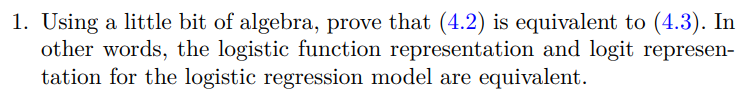
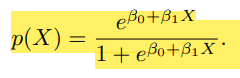
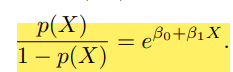

So, at first equation we see logistic function, that returns 0 and 1 - probababality, at the second equation we see logit representation:

$$p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$
Multiply both sides by:
$$
1 + e^{\beta_0 + \beta_1 X}$$
To get:
$$p(X) + p(X)e^{\beta_0 + \beta_1 X} = e^{\beta_0 + \beta_1 X}$$
Rearranging the terms:
$$
p(X) = e^{\beta_0 + \beta_1 X} - p(X)e^{\beta_0 + \beta_1 X}$$
Factoring out $e^{\beta_0 + \beta_1 X}$ and dividing both sides by the remainder:
$$\frac{p(X)}{1 - p(X)} = e^{\beta_0 + \beta_1 X}$$

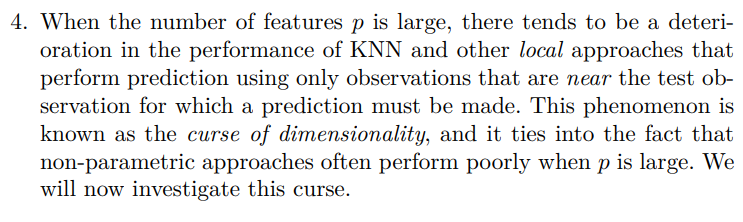

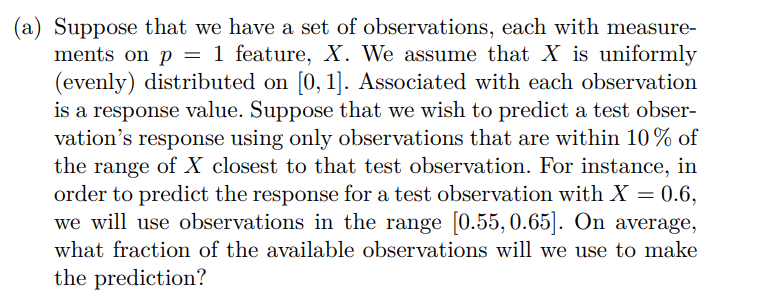

In [1]:
import numpy as np
import pandas as pd

obs = np.linspace(0, 1, 101)
range = 0.10
lim = range / 2

fractions = np.array([])

for test_obs in obs:
  left = test_obs - lim
  if left < 0:
    left = 0
    
  right = test_obs + lim
  if right > 1:
    right = 1
  
  fraction = right - left
  fractions = np.append(fractions, fraction)

print(fractions.mean())

0.09702970297029707


on average, the fraction of available observations we use to make the prediction is 9.7%, because if test points is in the start of in the end of interval, for example X = 0.02, so we can take negative numbers and will be = [X - 0.02, X + 0.05] = [0, 0.07], 7%, not 10%

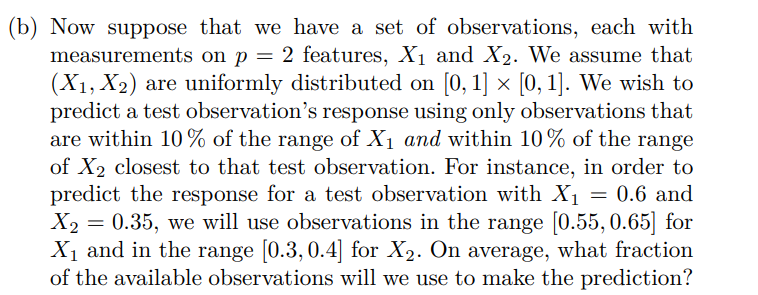

if we take higher dimensions, bunt ob thier own the fractions is the same - 0.97, then we can apply $a^{n}$

In [2]:
features = 2
fractions.mean() ** features

0.009414763258504077

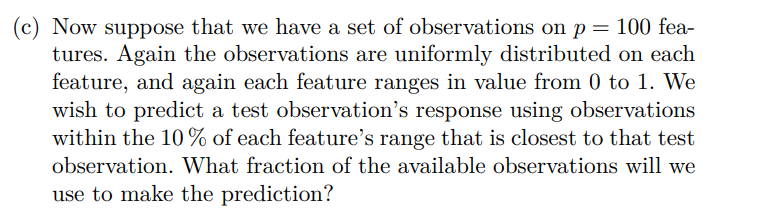

In [3]:
features = 100
fractions.mean() ** features

4.903093678840085e-102

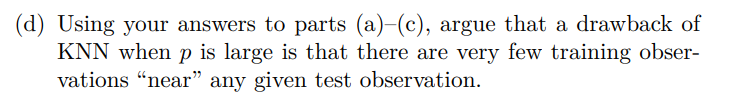

Now it`s obvious, because with higher dimension(num of features + 1), the number of used observartions in average is sligtly decresaig, because in case when all $X_i$ is some value in the start or in the end of range spoil all the pucture of this method, and it is very hard to find optimal nearest neighbors.

Also, with higher dimensions, the p-dimensional area is getting so big

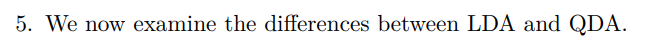

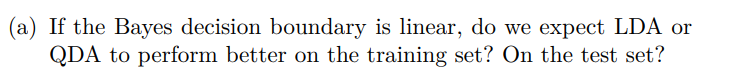

Bayes decision boundary

It’s the “gold standard” classifier: the one that minimizes test error if you knew the true class-conditional distributions.

Analogous to the “population regression line” in regression.

If the Bayes boundary is linear, that means the true conditional distributions (e.g. multivariate Gaussians with equal covariance matrices) lead to a linear separation rule.

So LDA is well-specified: it assumes linear boundaries, so it can match Bayes well (given enough data).

QDA is more flexible (quadratic boundary, separate covariance matrices for each class).

On the training set, QDA often fits better because it has more parameters and can “wiggle” to reduce training error.

But on the test set, since the true Bayes boundary is linear, that extra flexibility just adds variance → overfitting risk.

So LDA will usually do better on test in this situation.

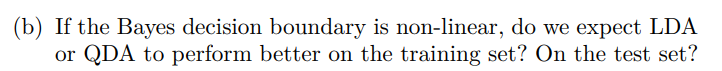

If the Bayes decision boundary is non-linear, that means that features are distributed with Gausisan distribution, but with difference covariance matrices.

If we have a lot amount pd data, that means that on the training and on the test set - QDA will better perform, because it has additional paramns to handle difficult patterns

But on small dataset, LDA can perform better on test set, since QDA will be overfitted by traning set

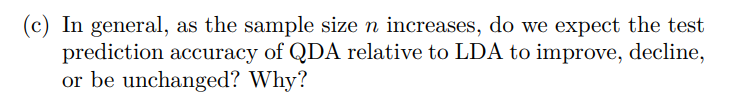

General principle

As n→∞, the effect of variance (overfitting) disappears — both LDA and QDA converge to their population versions.

So the relative performance depends only on how well their assumptions match the true distribution (i.e., whether the Bayes decision boundary is linear or not).

Two cases

Bayes decision boundary is linear (equal covariance matrices)

LDA is correctly specified → it converges to Bayes.

QDA is misspecified (too flexible) → still consistent, but with extra variance and unnecessary parameters.

With large 𝑛, LDA ≈ Bayes and outperforms QDA.

Bayes decision boundary is quadratic (different covariance matrices)

QDA is correctly specified → it converges to Bayes.

LDA is misspecified (can’t capture curvature) → always has bias.

With large 𝑛, QDA ≈ Bayes and outperforms LDA.

Small 𝑛

For small datasets, variance dominates → LDA may outperform QDA even if the Bayes boundary is quadratic.

This is the classic bias–variance tradeoff.

So the refined answer is:

As 𝑛 increases, the relative accuracy of QDA vs LDA depends on the true Bayes decision boundary.

If it’s linear, LDA does better in the limit.

If it’s non-linear, QDA does better in the limit. In general, the distribution of the data determines which model wins as the sample size grows.

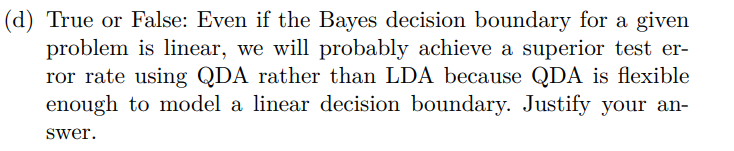

In case of linear Bayes decision boundary, we will achieve a superior test error using QDA, because QDA will have high variance. What this means? This means that QDA will strongly depend on chosen training dataset, and will be fitted to perform well ONLY on chosen traning dataset. BUT, if we choose another training set, or we choose some test set - the results will be very poor, since the Bayes decision boundary is linear, QDA will follow the noise, and will be oveerfitted.

Test error depends on bias-variance tradeoff, not flexibility.

Statement is false.

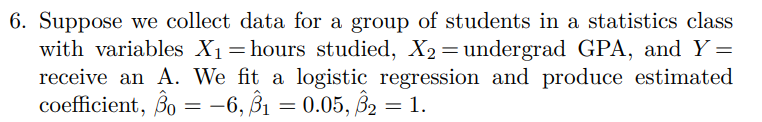

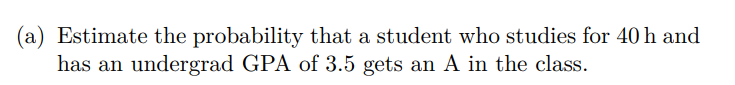

$X_1$ = hours studied \
$X_2$ = undergrad GPA \
Y = recieve an A

Used a logistic regression:
$$p(X)=\frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}.$$

$\beta_0$ = -6 \
$\beta_1$ = 0.05 \
$\beta_2$ = 1 

Test point:
- $X_1$ = 40
- $X_2$ = 3.5

In [4]:
betta_0 = -6 
betta_1 =  0.05
betta_2 =  1

def recieve_A(x1, x2):
  return (np.exp(betta_0 + betta_1 * x1 + betta_2 * x2)) /  \
         (1 + (np.exp(betta_0 + betta_1 * x1 + betta_2 * x2))) 

x1, x2 = 40, 3.5
prob =recieve_A(40, 3.5)
print(prob)

0.37754066879814546


The probability of recieving A is 38%

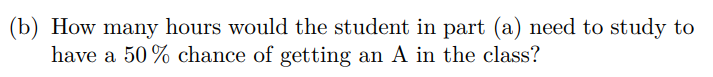

$$p(Hours,GPA)=\frac{e^{\beta_0+\beta_1*Hours+\beta_2*GPA}}{1+e^{\beta_0+\beta_1*Hours+\beta_2*GPA}}$$

In [5]:
hours_needed = 40
prob = 0.37754066879814546
gpa = 3.5

while prob < 0.5:
  hours_needed += 1
  prob = recieve_A(hours_needed, gpa)
  
print(hours_needed)
print(prob)

50
0.5


or we can take this formula:
$$\log \left( \frac{p(X)}{1 - p(X)} \right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$
where $X_1$ = hours needed

and derive to this:
$$X_1 = \frac{\log \left( \frac{p(X)}{1 - p(X)} \right) - \beta_0 - \beta_2 X_2}{\beta_1}
$$

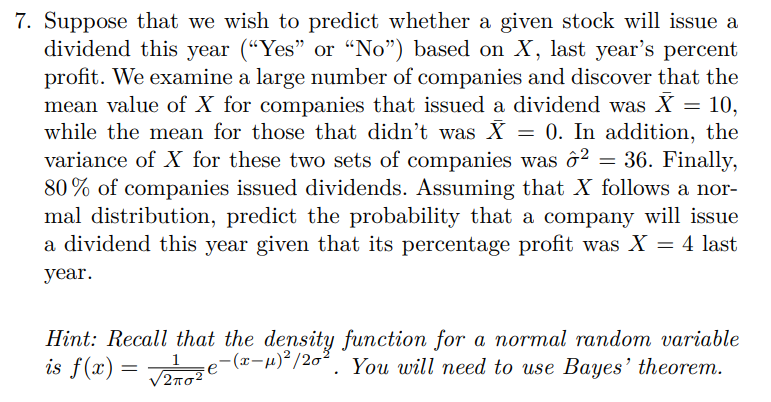

Y = "Yes" or "No" - will stock issue a divedend this year \
X - last year`s percent profit

We have two classes:
- A - company issue a divedend
- B - company does not issue a divedend

$\bar{X_A}=10$ - the mean value for X in A class \
$\bar{X_B}= 0$ - the mean value for X in A class

$\hat{\sigma_A}^{2} = \hat{\sigma_A}^{2} =36$ - variance of X is equal in class A and B

Since we know, that 80 % of companies issued dividends, I suppose that we can treat this as prior probability: \
$π_A = 0.8$ \
$π_B = 0.2$

Also we can assume that X followa a normal distribution


Based on facts above, we can use Bayes theorem and treat X as indepndent variable. We have prior and needed statistical values.

Posterior probability:$$\begin{aligned}
 & \Pr(Y=k|X=x)=\frac{\pi_k\times f_{k1}(x_1)\times f_{k2}(x_2)\times\cdots\times f_{kp}(x_p)}{\sum_{l=1}^K\pi_l\times f_{l1}(x_1)\times f_{l2}(x_2)\times\cdots\times f_{lp}(x_p)} \\
 & \mathrm{for~}k=1,\ldots,K.
\end{aligned}$$

First of all, for class A and class B we need probability density function, to describe how the X is distributed - $f(x_A)$ and $f(x_B)$

Since, X folloes Gaussian distribution, we can use its PDF:
$$f(x)=\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-(x-\mu)^{2}/2\sigma^{2}}$$

For Bayes theorem, we assume that all predctors are independent:
$$f_k(x) = f_{k1}(x_1) \times f_{k2}(x_2) \times \cdots \times f_{kp}(x_p),$$
but we have only one, so lets compute PDF for A and B

In [6]:
def gaussian_pdf(variance, mean, x):
    return (1 / np.sqrt(2 * np.pi * variance)) * np.exp(-((x - mean) ** 2) / (2 * variance))

In [7]:
mean_a = 10 
mean_b = 0
variance_a = variance_b = 36
x_test = 4

pdf_a = gaussian_pdf(variance_a, mean_a, x_test)
pdf_b = gaussian_pdf(variance_b, mean_b, x_test)

print(pdf_a)
print(pdf_b)

0.0403284540865239
0.053241334253725375


So know, we have some observation X = 4, and for each class compute posterior probability, and choose the max value of some kth class

In [8]:
import math

def bayes_theorem(priors, pdfs, k):
    numerator = priors[k] * pdfs[k]
    denominator = math.fsum(priors[j] * pdfs[j] for j in range(len(priors)))
    return numerator / denominator


In [9]:
# priors = [0.8, 0.2]
# pdfs = [0.0403284540865239, 0.053241334253725375]

# prob_of_A = bayes_theorem(priors, pdfs, 0)
# prob_of_B = bayes_theorem(priors, pdfs, 1)

# print(prob_of_A)
# print(prob_of_B)

THe ourput should be: \
p(Y = A | X) = 0.7516528925619835 \
p(Y = B | X) = 0.24834710743801653 

but my code do not want to work), though it has no errors

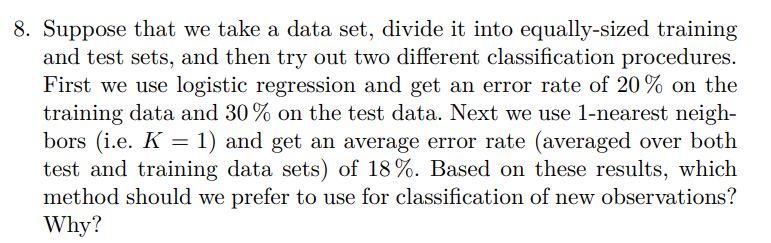

Lets make some notes:

Logistic regression:
- training error rate: 20%
- test error rate: 30%

1-nearest neighbors:
- average error rate: (training + test) / 2 = 18%

So, if we look at logistic regression and its results, the accuracy is not bad, and it is obvious that test error rate is higher then training

But, the main moment is in 1-nearest neighbors: average error rate = 18%.
At first it looks that this model better did its job, but...

The main idea of fitting models is to reduce TEST error. We do not care about training if our test error is high. So, it can be possible that training error rate is 0% and test is 36% and in average this is 18%. ALso it has 1 neighbor which is very flexible model

Logistic - high bias, low varince
1-nearest - low bias, high variance

Logistic regression is better because we care about test error, not traning or average

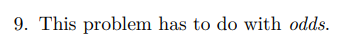

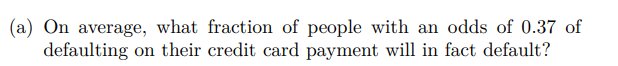

$$p(X)=\frac{odds}{1+odds} = \frac{0.37}{1+0.37}$$

In [10]:
0.37 / (1 + 0.37)

0.27007299270072993

27% of people will default with an odds of 0.37

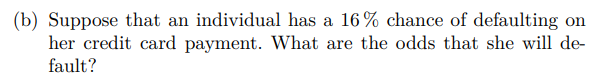

$$\frac{p(X)}{1-p(X)} = \frac{0.16}{1-0.16}$$

In [11]:
0.16 / (1 - 0.16)

0.1904761904761905

### Applied

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)
import seaborn as sns

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

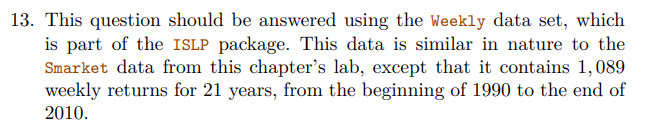

In [13]:
weekly = load_data("Weekly")
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [14]:
weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [15]:
weekly.shape

(1089, 9)

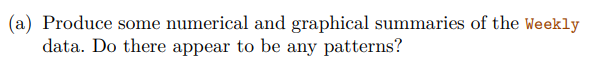

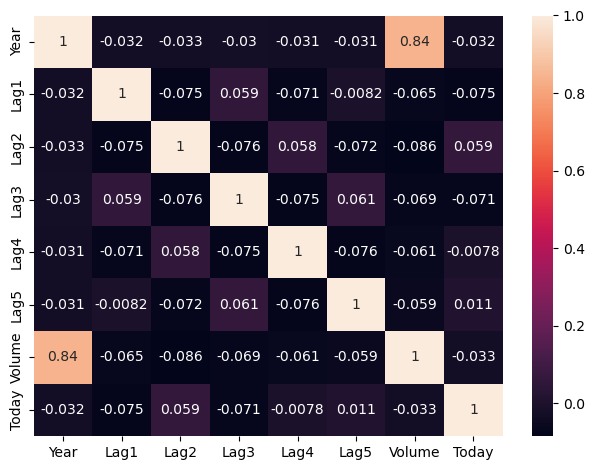

In [16]:
sns.heatmap(data=weekly.drop(columns=["Direction"]).corr(), annot=True)
plt.tight_layout()

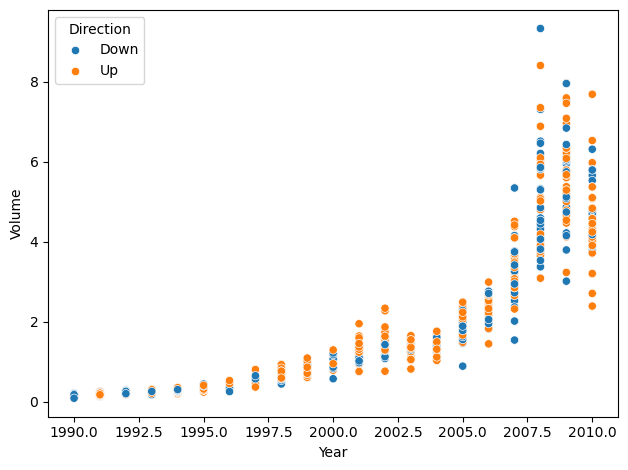

In [17]:
sns.scatterplot(data=weekly, x="Year", y="Volume", hue="Direction", )
plt.tight_layout()

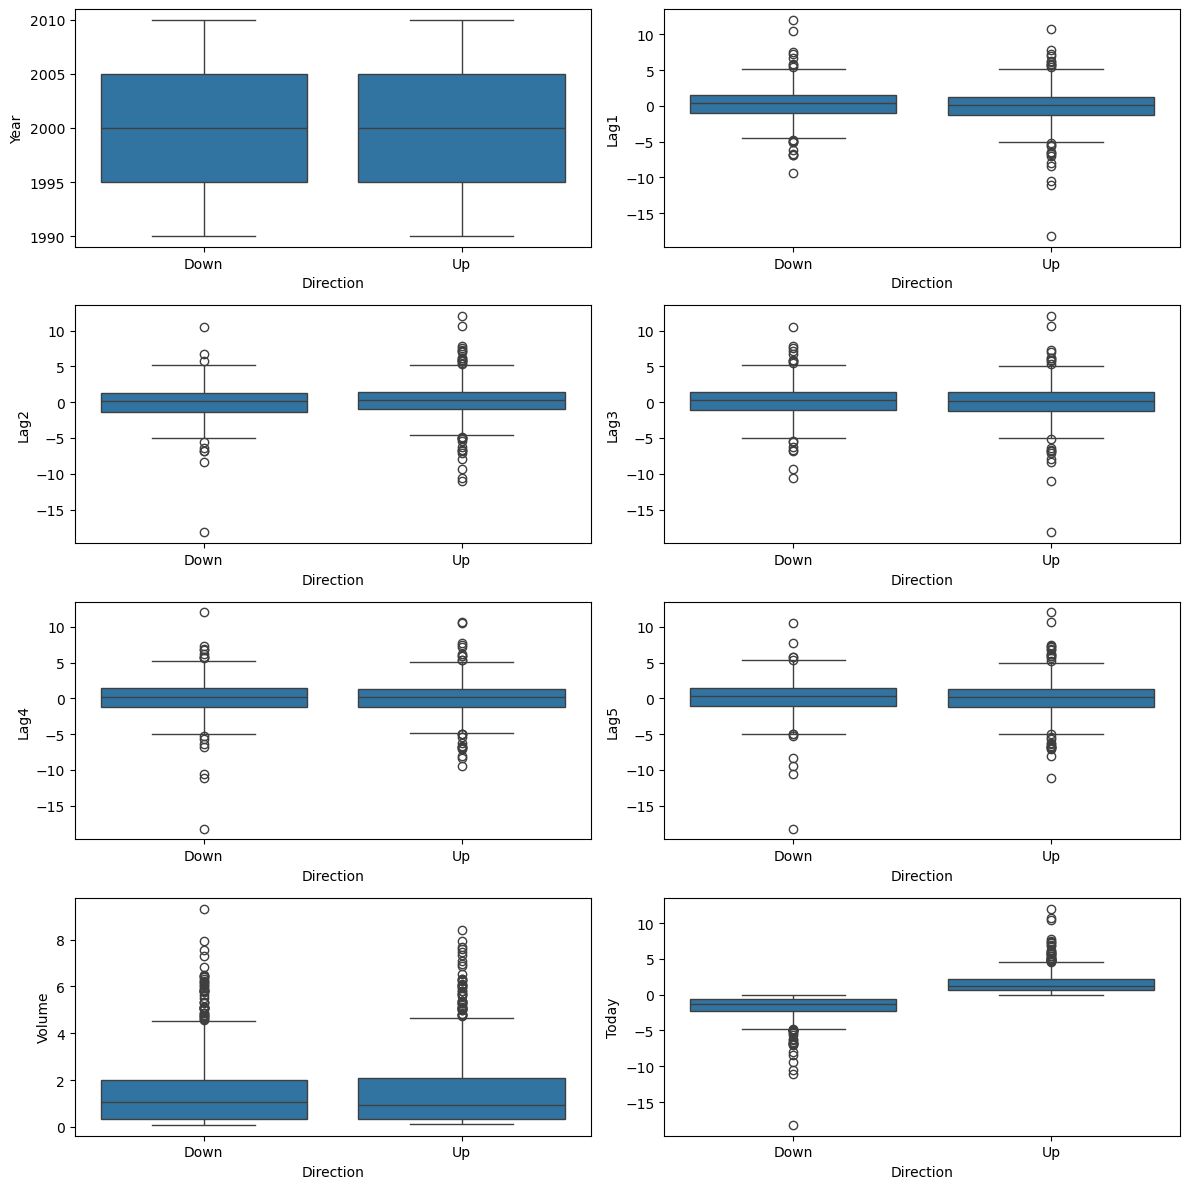

In [18]:
features = weekly.drop(columns=["Direction"]).columns
n_cols = 2
n_rows = int(np.ceil(len(features) / n_cols))

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 3 * n_rows))
ax = ax.flatten()

for i, x in enumerate(features):
    sns.boxplot(data=weekly, x="Direction", y=x, ax=ax[i])

plt.tight_layout()

In [19]:
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [20]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


Based on numerical and graphical: 
- there is some correlation between `Volume` and `Year`. Also we see trend, that with `Year` increasing `Volume` is also increasing and this is continuing for almost all years 
- also from boxplot we see, that in `Today` feature: observations that has values greater than zero has `Up` class 

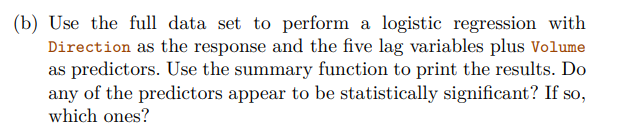

In [58]:
vars = features.drop(["Year", "Today"])
design = MS(vars)

X = design.fit_transform(weekly)
y = weekly["Direction"] == "Up"

glm = sm.GLM(y, X, family=sm.families.Binomial())
results_1 = glm.fit()
summarize(results_1)


,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


As we can see, only `Lag2` seems to be statistical significant

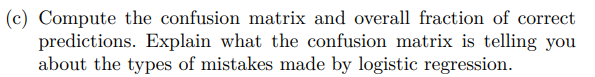

In [22]:
pred_probs = results_1.predict()
pred_probs[:10]

array([0.60862494, 0.60103144, 0.58756995, 0.48164156, 0.61690129,
       0.56841902, 0.57860971, 0.51519724, 0.57151998, 0.55542873])

In [23]:
pred_labels = np.array(weekly.shape[0] * ["Down"])
pred_labels[pred_probs > 0.5] = "Up"
pred_labels

array(['Up', 'Up', 'Up', ..., 'Up', 'Up', 'Up'], dtype='<U4')

In [24]:
confusion_table(pred_labels, weekly["Direction"])

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [25]:
(np.mean(pred_labels == weekly["Direction"]), 
np.mean(pred_labels != weekly["Direction"]))

(0.5610651974288338, 0.4389348025711662)

In [26]:
(557 + 48) / weekly.shape[0]

0.5555555555555556

Above we see the results of logistic regression. The accuracy(percent of true predicted observations) is 56% and 44% of error rate. It is 5% better than random guessing(50%), but it is only (0.55%) better than null classifier(55%)

In confusion matrix we see, that:
- we predicted 102 observations to have class "Down", when only 54 of them has it
- we predicted 987 observations to have class "Up", when only 557 of tehm has it

In general, logistic regression has accuracy rate more than 50% for one and other class

It have learnt something, but the results are not significant

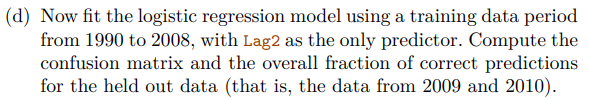

In [27]:
vars = ["Lag2"]
design = MS(vars)

training_set, test_set = weekly[weekly["Year"] < 2009], \
                         weekly[weekly["Year"] >= 2009]

X_train = design.fit_transform(training_set)
y_train = training_set["Direction"] == "Up"

glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results_2 = glm.fit()

summarize(results_2)


,coef,std err,z,P>|z|
intercept,0.2033,0.064,3.162,0.002
Lag2,0.0581,0.029,2.024,0.043


In [28]:
X_test = design.fit_transform(test_set)

pred_y_prob = results_2.predict(X_test)
pred_y_prob[:5]

985    0.526129
986    0.644736
987    0.486216
988    0.485200
989    0.519767
dtype: float64

In [29]:
test_set.shape

(104, 9)

In [30]:
pred_labels = np.array(["Down"] * test_set.shape[0])
pred_labels[pred_y_prob > 0.5] = "Up"

true_labels = test_set["Direction"]

In [31]:
confusion_table(pred_labels, true_labels)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [32]:
model_comparison = pd.DataFrame({"model": [], "accuracy": []})

In [33]:

accuracy_rate = np.mean(pred_labels == true_labels)
error_rate = np.mean(pred_labels != true_labels)
null_classifier = (56 + 5) / 104

model_comparison.loc[len(model_comparison)] = ["logistic_regression", accuracy_rate]

print(f"Accuracy rate: {accuracy_rate:.3f}")
print(f"Error rate: {error_rate:.3f}")
print(f"Null classifier rate: {null_classifier:.3f}")
print(f"Rsndom guessing: 0.5")

Accuracy rate: 0.625
Error rate: 0.375
Null classifier rate: 0.587
Rsndom guessing: 0.5


We see, than know, logistic model, fitted only with predictor `Lag2` which has small p-value, showed better results.

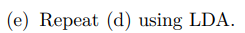

In [34]:
X_train = design.fit_transform(training_set)
X_test = design.fit_transform(test_set)
L_train = training_set["Direction"]
L_test = test_set["Direction"]

In [35]:
lda = LDA(store_covariance=True)
lda

LinearDiscriminantAnalysis(store_covariance=True)

In [36]:
lda_model = lda.fit(X_train, L_train)
lda_model

LinearDiscriminantAnalysis(store_covariance=True)

In [37]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [38]:
lda.means_

array([[ 1.        , -0.03568254],
       [ 1.        ,  0.26036581]])

In [39]:
lda.priors_

array([0.44771574, 0.55228426])

In [40]:
lda.scalings_

array([[ 0.        ],
       [-0.44141622]])

In [41]:
pred_labels = lda.predict(X_test)
pred_labels[:5]

array(['Up', 'Up', 'Down', 'Down', 'Up'], dtype='<U4')

In [42]:
confusion_table(pred_labels, L_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [43]:
model_comparison.loc[len(model_comparison)] = ["lda", 
                                           (9 + 56) / 104]

Here we see that the results are indentical like in logistic regression

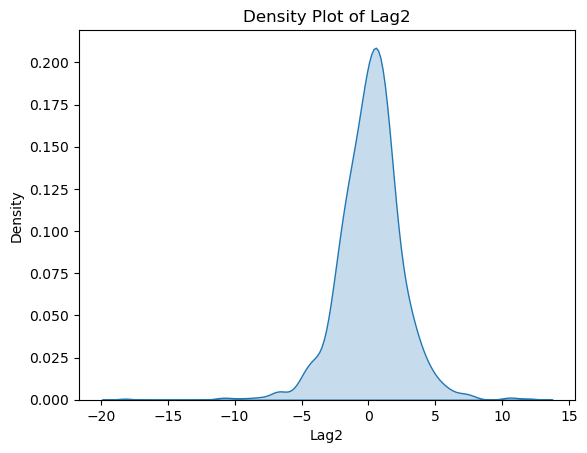

In [44]:
sns.kdeplot(weekly["Lag2"], fill=True)
plt.xlabel("Lag2")
plt.title("Density Plot of Lag2")
plt.show()

In [45]:
qda = QDA(store_covariance=True)
qda

QuadraticDiscriminantAnalysis(store_covariance=True)

In [46]:
pred_labels = qda.fit(X_train, L_train).predict(X_test)
confusion_table(pred_labels, L_test)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:972: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:972: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:975: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])


Truth,Down,Up
Predicted,,
Down,43,61
Up,0,0


In [47]:
accuracy_rate = np.mean(pred_labels == L_test)
error_rate = np.mean(pred_labels != L_test)
null_classifier = (61 + 0) / 104

model_comparison.loc[len(model_comparison)] = ["qda", 0.586]

print(f"Accuracy rate: {accuracy_rate:.3f}")
print(f"Error rate: {error_rate:.3f}")
print(f"Null classifier rate: {null_classifier:.3f}")
print(f"Rsndom guessing: 0.5")

Accuracy rate: 0.413
Error rate: 0.587
Null classifier rate: 0.587
Rsndom guessing: 0.5


With QDA is some bug, the results have to be:
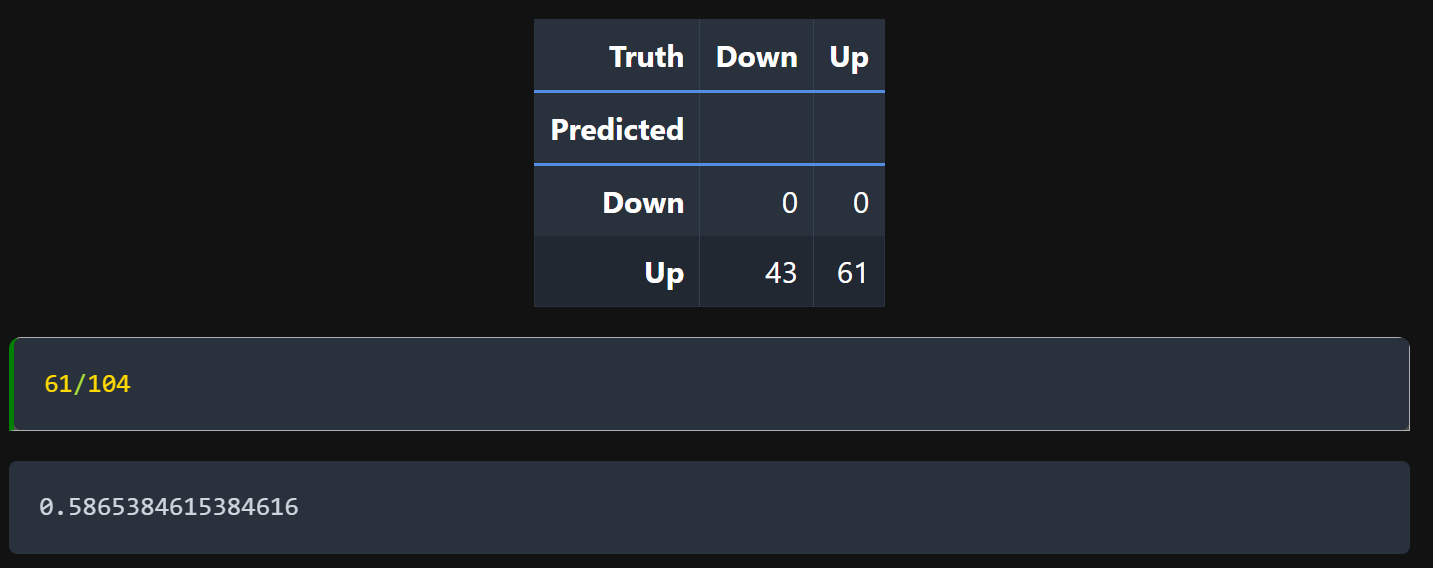

In [48]:
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1

KNeighborsClassifier(n_neighbors=1)

In [49]:
pred_labels = knn_1.fit(X_train, L_train).predict(X_test)
confusion_table(pred_labels, L_test)

Truth,Down,Up
Predicted,,
Down,22,31
Up,21,30


In [50]:
accuracy_rate = np.mean(pred_labels == L_test)
error_rate = np.mean(pred_labels != L_test)
null_classifier = (61 + 0) / 104

model_comparison.loc[len(model_comparison)] = ["knn-1", accuracy_rate]

print(f"Accuracy rate: {accuracy_rate:.3f}")
print(f"Error rate: {error_rate:.3f}")
print(f"Null classifier rate: {null_classifier:.3f}")
print(f"Rsndom guessing: 0.5")

Accuracy rate: 0.500
Error rate: 0.500
Null classifier rate: 0.587
Rsndom guessing: 0.5


K-nearest neighbors also shows bad results, the same as random guessing and much worse than null classifier

In [51]:
NB = GaussianNB()
pred_labels = NB.fit(X_train, L_train).predict(X_test)
confusion_table(pred_labels, L_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [52]:
accuracy_rate = np.mean(pred_labels == L_test)
error_rate = np.mean(pred_labels != L_test)
null_classifier = (61 + 0) / 104

model_comparison.loc[len(model_comparison)] = ["naive bayes", accuracy_rate]

print(f"Accuracy rate: {accuracy_rate:.3f}")
print(f"Error rate: {error_rate:.3f}")
print(f"Null classifier rate: {null_classifier:.3f}")
print(f"Rsndom guessing: 0.5")

Accuracy rate: 0.587
Error rate: 0.413
Null classifier rate: 0.587
Rsndom guessing: 0.5


In [53]:
model_comparison

,model,accuracy
0,logistic_regression,0.625000
1,lda,0.625000
2,qda,0.586000
3,knn-1,0.500000
4,naive bayes,0.586538


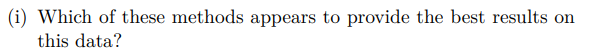

<Axes: xlabel='model', ylabel='accuracy'>

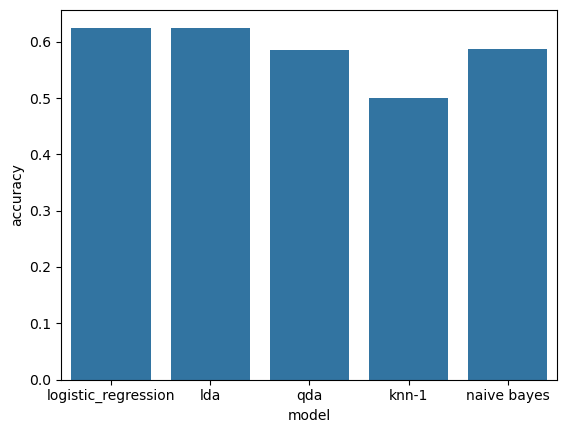

In [54]:
sns.barplot(data=model_comparison, x="model", y="accuracy")

In `Weekly` dataset, linear models like logistic regression anf lda showed the best results

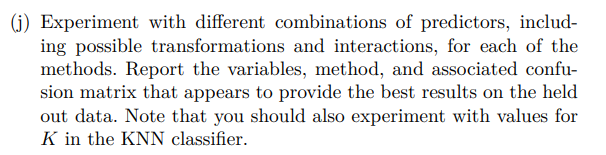

In [66]:
def fit_and_predict(model, model_name):
  # X_train = design.fit_transform(training_set)
  # X_test = design.fit_transform(test_set)
  # L_train = training_set["Direction"]
  # L_test = test_set["Direction"]
  
  pred_labels = model.fit(X_train, L_train).predict(X_test)
  print(confusion_table(pred_labels, L_test))
  
  accuracy_rate = np.mean(pred_labels == L_test)
  error_rate = np.mean(pred_labels != L_test)
  null_classifier = (61 + 0) / 104

  model_comparison.loc[len(model_comparison)] = [model_name, accuracy_rate]

  print(f"Accuracy rate: {accuracy_rate:.3f}")
  print(f"Error rate: {error_rate:.3f}")
  print(f"Null classifier rate: {null_classifier:.3f}")
  print(f"Rsndom guessing: 0.5")

SInce `Lag2` - the predictor with smallest p-value, so i will use it, and since linear predictors show great results, lets add some combinations to it

In [70]:
from ISLP.models import poly

design = MS([poly("Lag2", 3)])
model = lda

fit_and_predict(model, "cubic lda")

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56
Accuracy rate: 0.625
Error rate: 0.375
Null classifier rate: 0.587
Rsndom guessing: 0.5


In [100]:
def fit_and_predict_knn(k):
  model = KNeighborsClassifier(n_neighbors=k)
  pred_labels = model.fit(X_train, L_train).predict(X_test)
  
  conf_tabl = confusion_table(pred_labels, L_test)
  
  accuracy_rate = np.mean(pred_labels == L_test)
  null_classifier = (conf_tabl.iloc[1]["Up"] + 0) / X_test.shape[0]
  
  return [k, accuracy_rate, null_classifier]

In [102]:
k_values = np.linspace(1, 100, 100)
k_neighbors_results =pd.DataFrame({"k": [], 
                                   "accuracy_rate": [],
                                   "null_classifier": []})
k_values = k_values.astype(int)

for k in k_values:
  k_neighbors_results.loc[len(k_neighbors_results)] = fit_and_predict_knn(k)


In [103]:
k_neighbors_results

,k,accuracy_rate,null_classifier
0,1.0,0.500000,0.288462
1,2.0,0.471154,0.173077
2,3.0,0.548077,0.394231
3,4.0,0.576923,0.326923
4,5.0,0.538462,0.384615
...,...,...,...
95,96.0,0.596154,0.500000
96,97.0,0.596154,0.500000
97,98.0,0.567308,0.461538
98,99.0,0.586538,0.480769


In [107]:
index_max = k_neighbors_results["accuracy_rate"].idxmax()
k_neighbors_results.iloc[index_max]

k                  47.000000
accuracy_rate       0.615385
null_classifier     0.394231
Name: 46, dtype: float64

In [108]:
index_min = k_neighbors_results["accuracy_rate"].idxmin()
k_neighbors_results.iloc[index_min]

k                  2.000000
accuracy_rate      0.471154
null_classifier    0.173077
Name: 1, dtype: float64

KNN model with k = 47 and accuracy rate = 61.5% showed the best results 

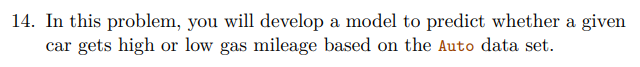

In [109]:
auto = load_data("Auto")
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [110]:
auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [111]:
auto.shape

(392, 8)

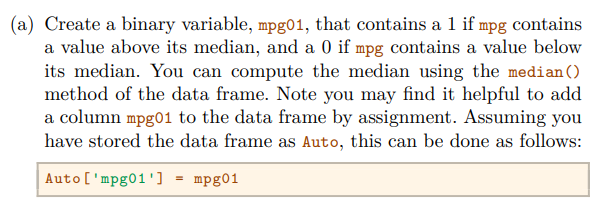

In [113]:
auto["mpg"]

name
chevrolet chevelle malibu    18.0
buick skylark 320            15.0
plymouth satellite           18.0
amc rebel sst                16.0
ford torino                  17.0
                             ... 
ford mustang gl              27.0
vw pickup                    44.0
dodge rampage                32.0
ford ranger                  28.0
chevy s-10                   31.0
Name: mpg, Length: 392, dtype: float64

In [ ]:
auto["mpg"].describe()

count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [130]:
#create target variable 

mpg = auto.mpg
mpg_median = mpg.median()

auto["mpg_01"] = (mpg > mpg_median).astype(int)
auto["mpg_01"]

name
chevrolet chevelle malibu    0
buick skylark 320            0
plymouth satellite           0
amc rebel sst                0
ford torino                  0
                            ..
ford mustang gl              1
vw pickup                    1
dodge rampage                1
ford ranger                  1
chevy s-10                   1
Name: mpg_01, Length: 392, dtype: int32

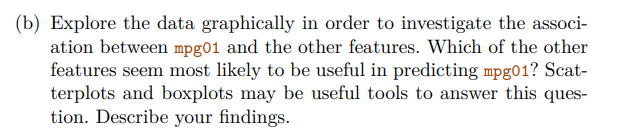

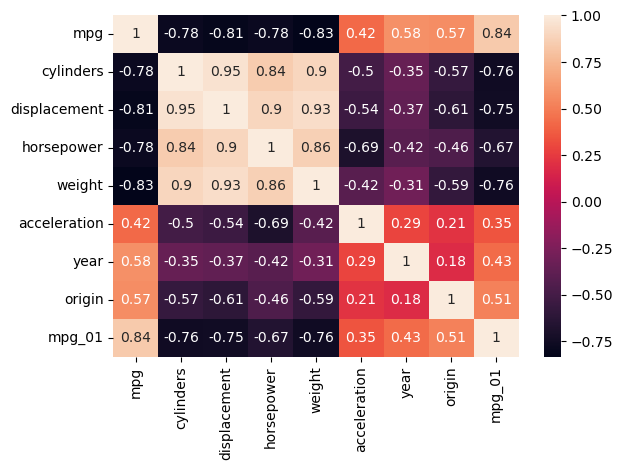

In [133]:
sns.heatmap(auto.corr(), annot=True)
plt.tight_layout()

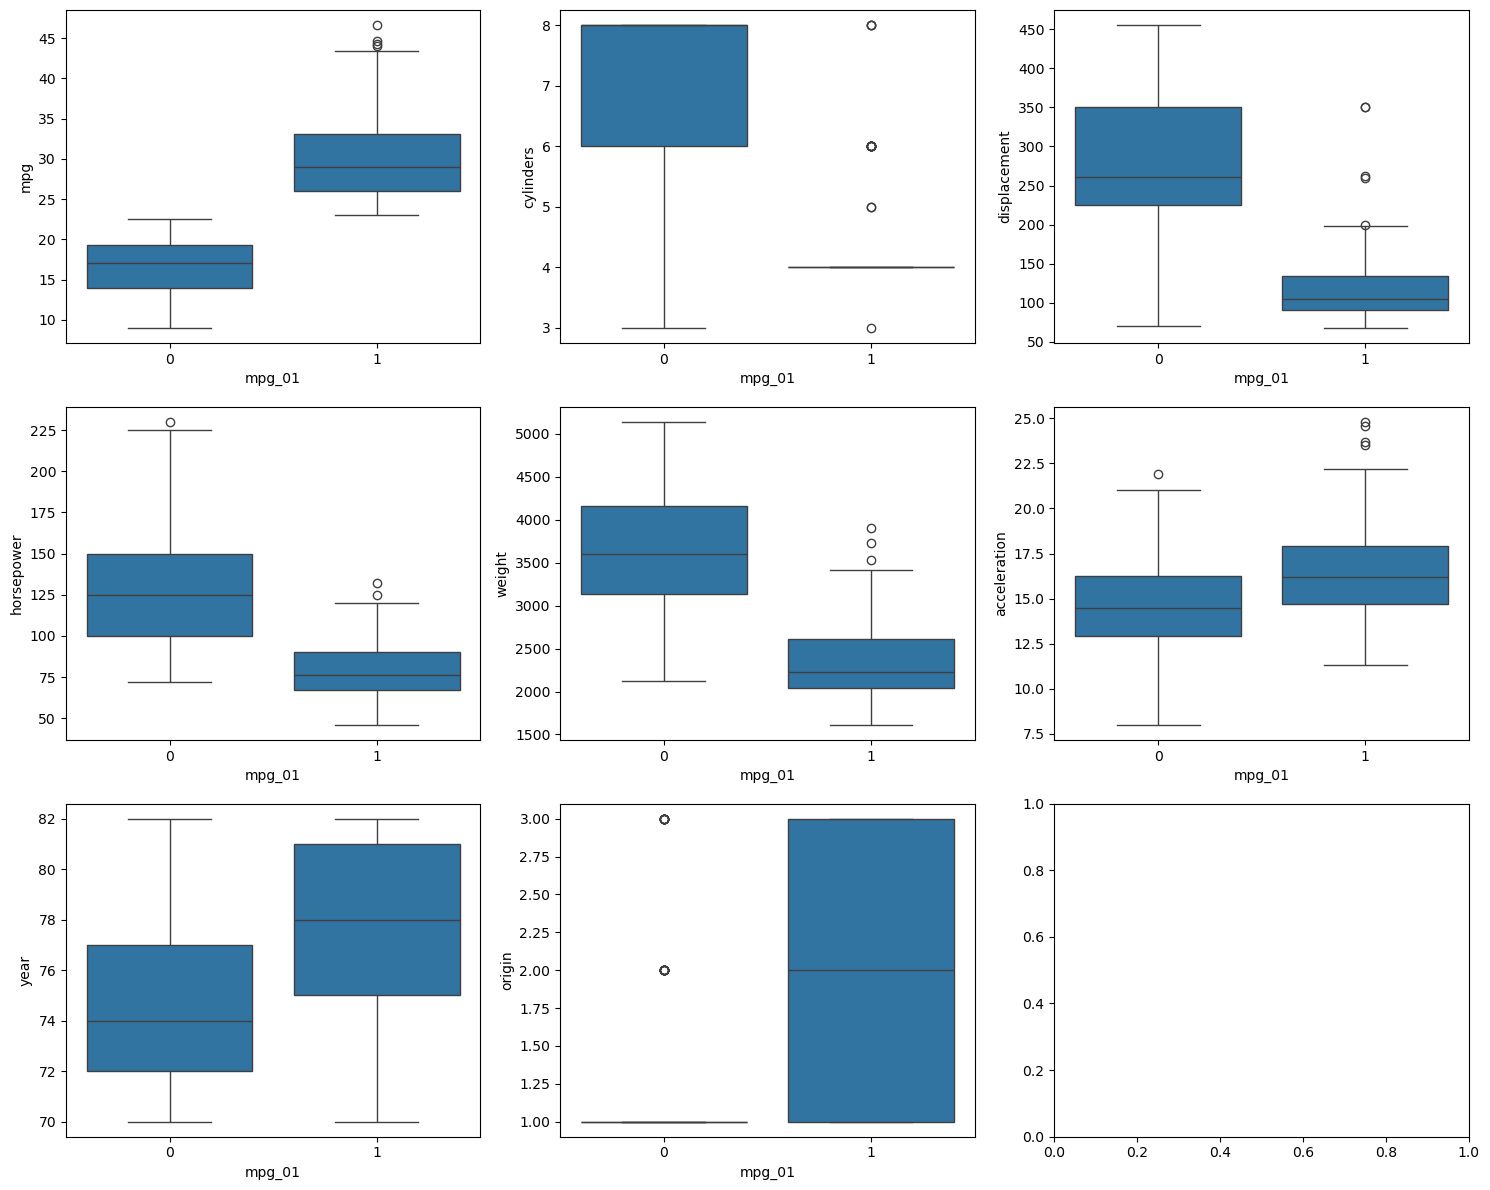

In [148]:
features = auto.columns.drop("mpg_01").to_list() 

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows))
ax = ax.flatten()

for i, x in enumerate(features):
    sns.boxplot(data=auto, x="mpg_01", y=x, ax=ax[i])

plt.tight_layout()

We see, that many features are associated with `mpg_01`

The most useful in my opinion are: `cylinders`, `displacement`, `horsepower`, `weight`

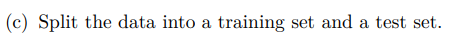

In [164]:
X = auto[["cylinders", "displacement", "horsepower", "weight"]]
y = auto["mpg_01"]

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size=0.3, 
                                                   random_state=1)

print(X.shape[0])
(X_train.shape, X_test.shape)

392


((274, 4), (118, 4))

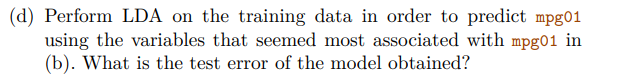

In [172]:
def compute_metrics(pred_labels, y_test):
  conf_matr = confusion_table(pred_labels, y_test)

  accuracy_rate = np.mean(pred_labels == y_test)
  error_rate = 1 - accuracy_rate
  null_classifier = y_test.value_counts().max() / len(y_test)

  print(conf_matr)
  print(f"accuracy_rate: {accuracy_rate}")
  print(f"error_rate: {error_rate}")
  print(f"null_classifier: {null_classifier}")
  
  return error_rate

In [167]:
lda = LDA(store_covariance=True)
pred_labels = lda.fit(X_train, y_train).predict(X_test)

compute_metrics(pred_labels, y_test)

Truth       0   1
Predicted        
0          58   3
1           7  50
accuracy_rate: 0.9152542372881356
error_rate: 0.0847457627118644
null_classifier: 0.5508474576271186


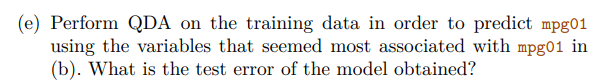

We see, that LDA showed quite impressive results. Test error rate is 8.5%

In [168]:
qda = QDA(store_covariance=True)
pred_labels = qda.fit(X_train, y_train).predict(X_test)

compute_metrics(pred_labels, y_test)

Truth       0   1
Predicted        
0          61   5
1           4  48
accuracy_rate: 0.923728813559322
error_rate: 0.07627118644067798
null_classifier: 0.5508474576271186


QDA showed a little bit better result, maybe we have some non-linear trend for treshhold

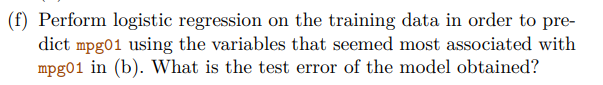

In [170]:
glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
probs = glm.fit().predict(X_test)
pred_labels = (probs > 0.5).astype(int)

compute_metrics(pred_labels, y_test)

Truth       0   1
Predicted        
0          56   6
1           9  47
accuracy_rate: 0.8728813559322034
error_rate: 0.1271186440677966
null_classifier: 0.5508474576271186


Logistic regression showed worser results than QDA and LDA

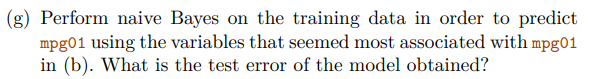

In [171]:
NB = GaussianNB()
pred_labels = NB.fit(X_train, y_train).predict(X_test)

compute_metrics(pred_labels, y_test)

Truth       0   1
Predicted        
0          60   5
1           5  48
accuracy_rate: 0.9152542372881356
error_rate: 0.0847457627118644
null_classifier: 0.5508474576271186


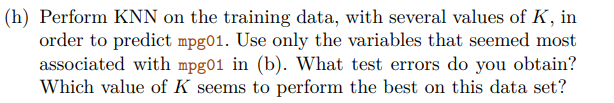

In [173]:
best_knn = {"k": 0, "error_rate": 1}
k_values = np.linspace(1, 50, 50).astype(int)

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  pred_labels = knn.fit(X_train, y_train).predict(X_test)
  
  error_rate = compute_metrics(pred_labels, y_test)
  
  if error_rate < best_knn["error_rate"]:
    best_knn["k"] = k
    best_knn["error_rate"] = error_rate
  
best_knn

Truth       0   1
Predicted        
0          55   4
1          10  49
accuracy_rate: 0.8813559322033898
error_rate: 0.11864406779661019
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          59   9
1           6  44
accuracy_rate: 0.8728813559322034
error_rate: 0.1271186440677966
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          58   6
1           7  47
accuracy_rate: 0.8898305084745762
error_rate: 0.11016949152542377
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          61   9
1           4  44
accuracy_rate: 0.8898305084745762
error_rate: 0.11016949152542377
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          55   6
1          10  47
accuracy_rate: 0.864406779661017
error_rate: 0.13559322033898302
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          59   6
1           6  47
accuracy_rate: 0.8983050847457628
error_rate: 0.101694915254

{'k': 8, 'error_rate': 0.0847457627118644}

Since KNN is a distance and in feature space a crucial role has scale of features. So, lets scale them to standard deviation of 1 anf mean in 0

In [182]:
scaler = StandardScaler(with_mean=True,
                        with_std=True,
                        copy=True)

X = auto[['cylinders', 'displacement', 'horsepower', 'weight']]
y = auto['mpg_01']

X_std = scaler.fit_transform(X)

scaled_features = pd.DataFrame(data=X_std, columns=X.columns)

print(scaled_features["cylinders"].std())
print(scaled_features["cylinders"].mean())

1.0012779557930158
-1.0875654118777043e-16


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features, y, 
                                                    test_size=0.30, 
                                                    random_state=1)



In [184]:
best_knn = {"k": 0, "error_rate": 1}
k_values = np.linspace(1, 50, 50).astype(int)

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  pred_labels = knn.fit(X_train, y_train).predict(X_test)
  
  error_rate = compute_metrics(pred_labels, y_test)
  
  if error_rate < best_knn["error_rate"]:
    best_knn["k"] = k
    best_knn["error_rate"] = error_rate
  
best_knn

Truth       0   1
Predicted        
0          57   6
1           8  47
accuracy_rate: 0.8813559322033898
error_rate: 0.11864406779661019
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          63   8
1           2  45
accuracy_rate: 0.9152542372881356
error_rate: 0.0847457627118644
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          59   6
1           6  47
accuracy_rate: 0.8983050847457628
error_rate: 0.10169491525423724
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          63   7
1           2  46
accuracy_rate: 0.923728813559322
error_rate: 0.07627118644067798
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          60   5
1           5  48
accuracy_rate: 0.9152542372881356
error_rate: 0.0847457627118644
null_classifier: 0.5508474576271186
Truth       0   1
Predicted        
0          61   6
1           4  47
accuracy_rate: 0.9152542372881356
error_rate: 0.0847457627118

{'k': 8, 'error_rate': 0.05932203389830504}

Now we see, that standartization plays a crucial role in distance methods:
- error rate without scaling:0.0847457
- error rate with scaling: 0.0593

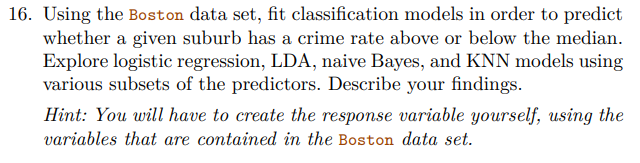

In [185]:
boston = load_data("Boston")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [186]:
boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [187]:
boston.shape

(506, 13)

In [188]:
boston["high_crime"] = (boston["crim"] > boston.crim.median()).astype(int)

boston["high_crime"].value_counts()

high_crime
0    253
1    253
Name: count, dtype: int64

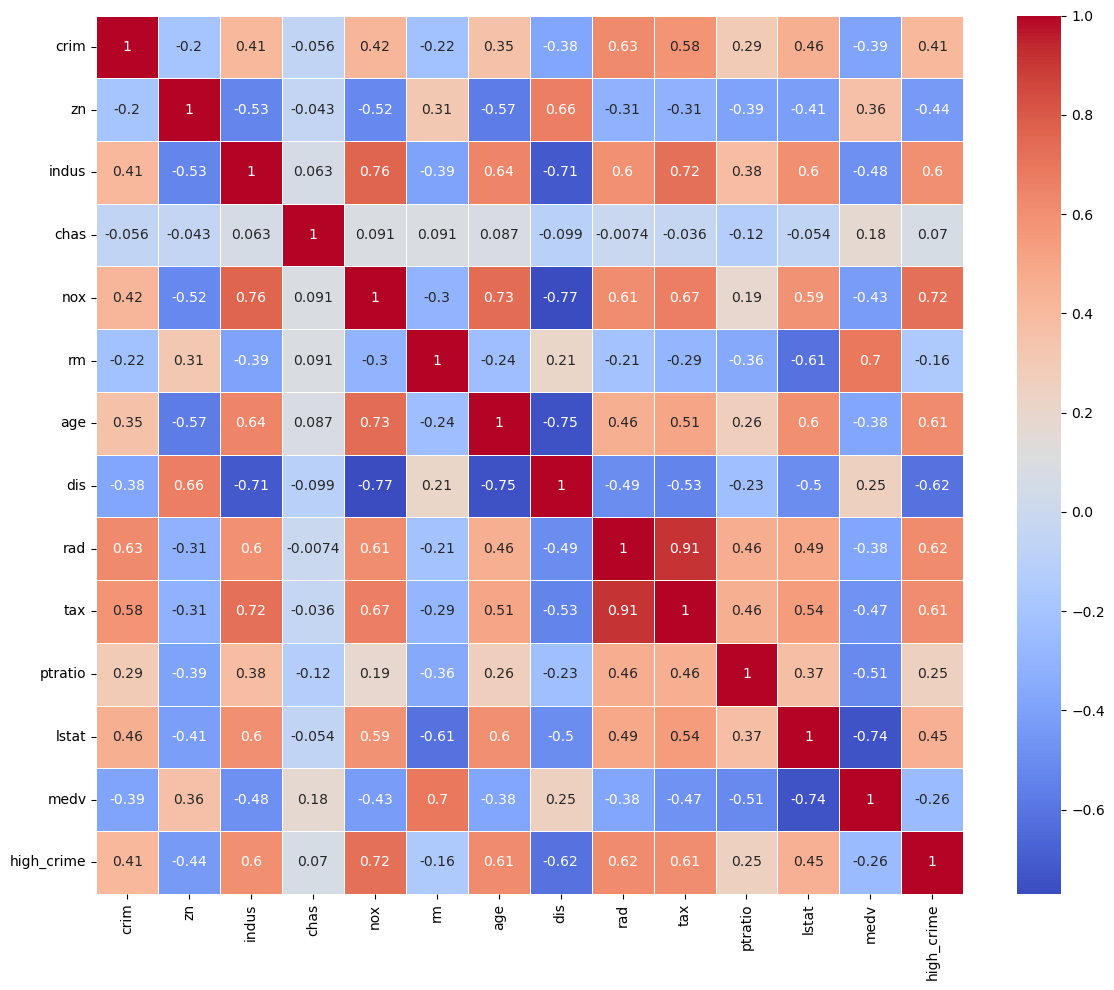

In [192]:
plt.figure(figsize=(12, 10)) 
sns.heatmap(boston.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.tight_layout()


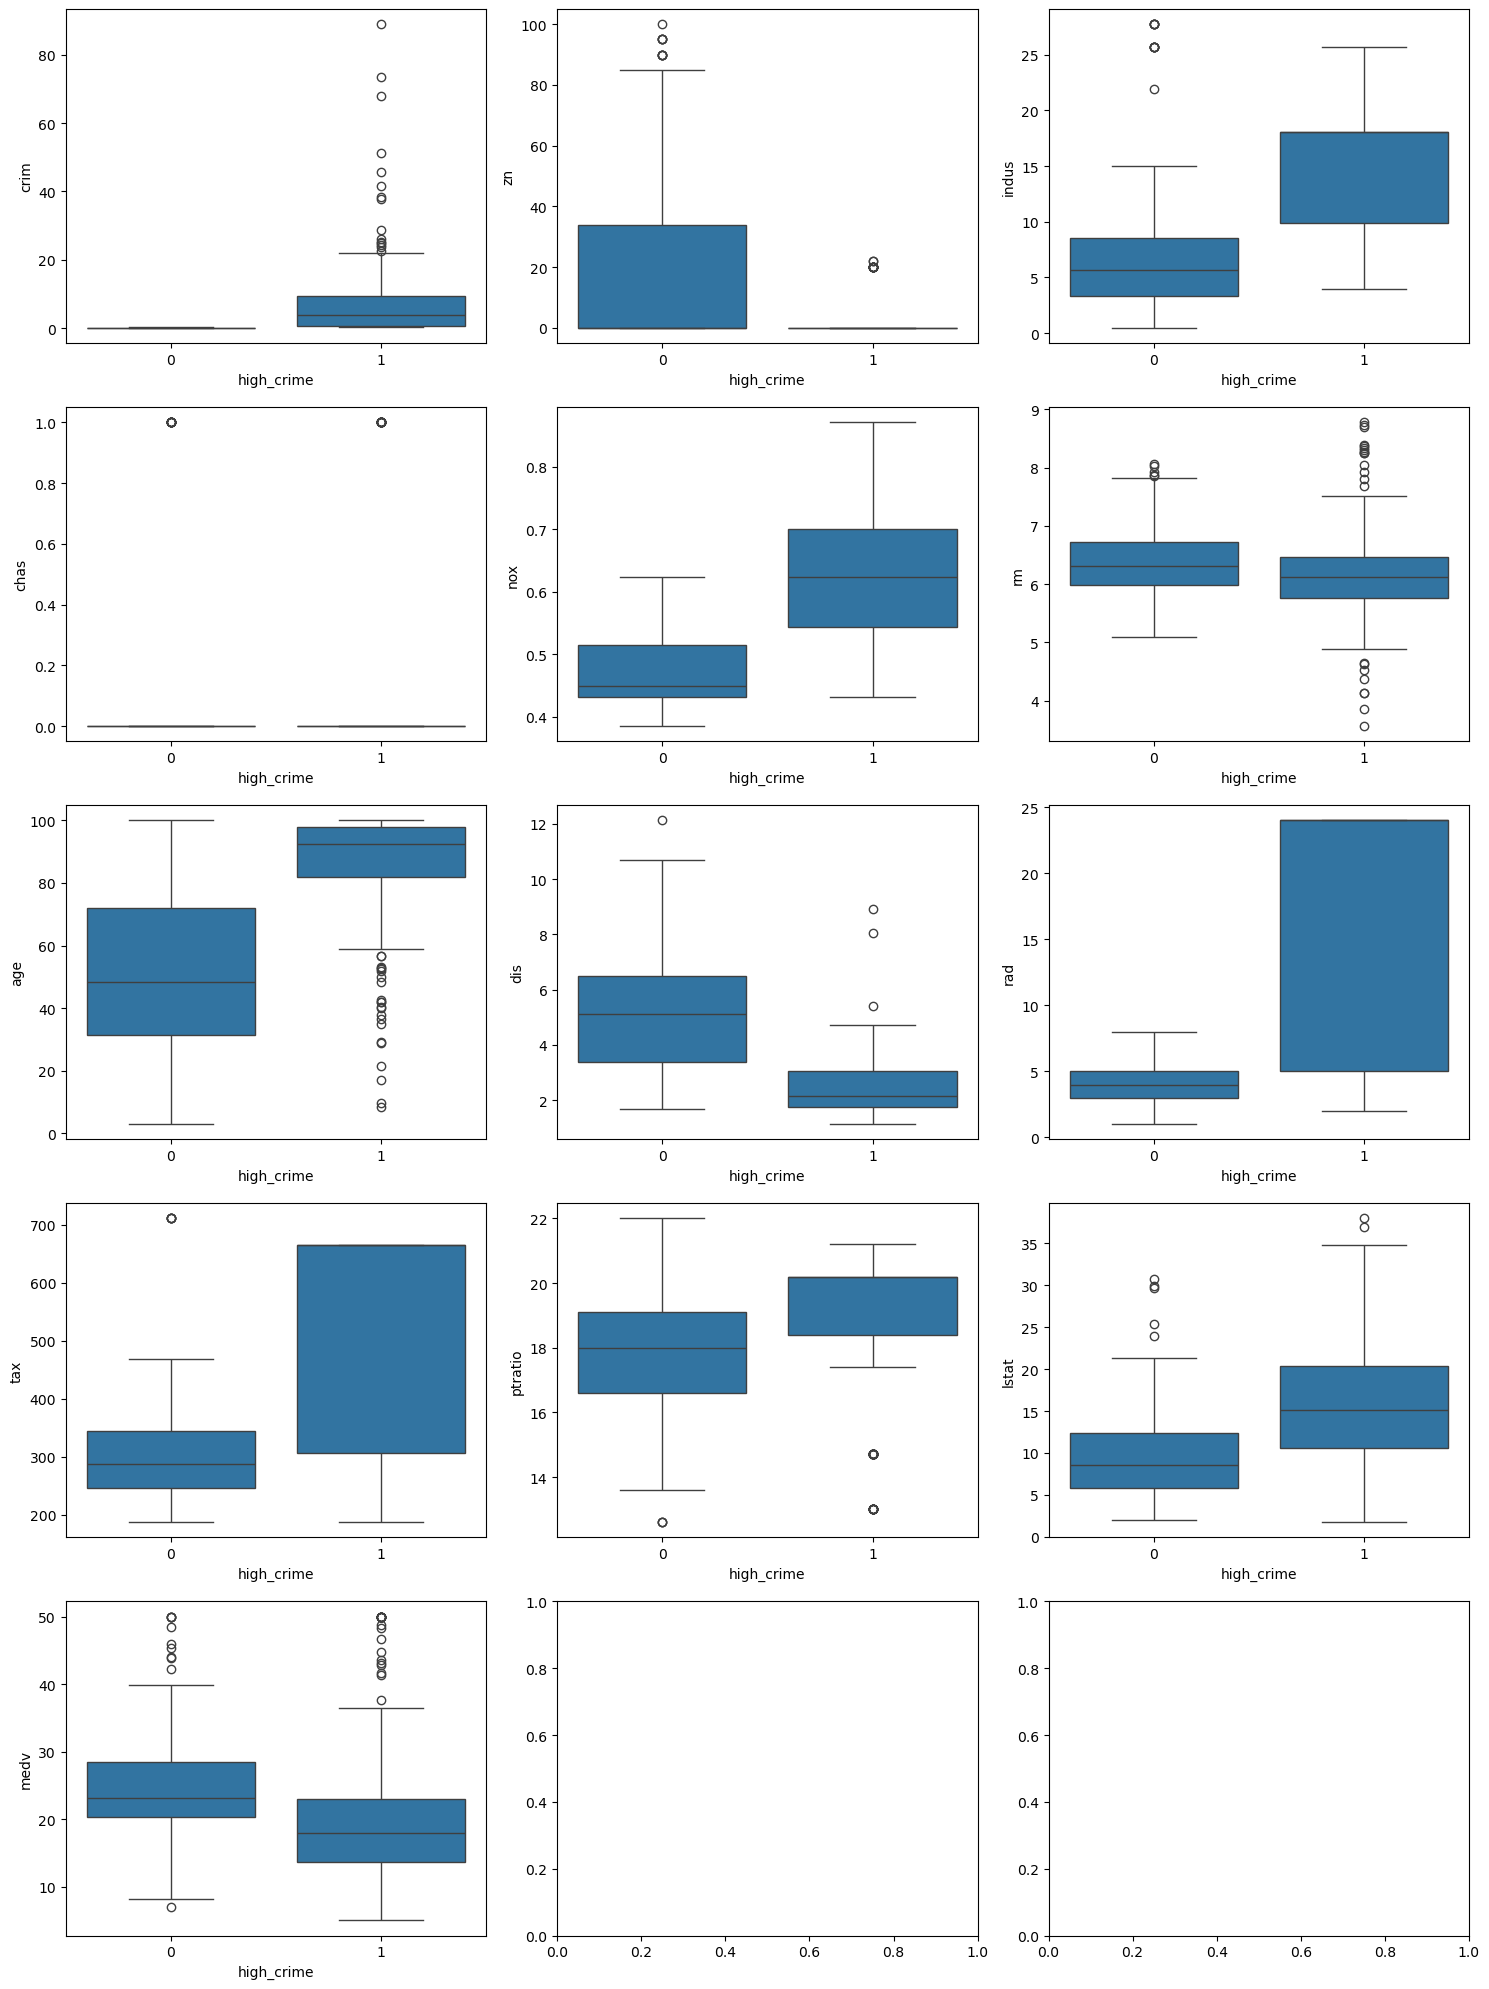

In [194]:
features = boston.columns.drop("high_crime").to_list() 

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows))
ax = ax.flatten()

for i, x in enumerate(features):
    sns.boxplot(data=boston, x="high_crime", y=x, ax=ax[i])

plt.tight_layout()

So, according to analysis, i choose the most significant features like: `indus`, `nox`, `age`, `dis`, `rad`, `tax`

In [198]:
X = boston[["indus", "nox", "age", "dis", "rad", "tax"]]
y = boston["high_crime"]

In [199]:
def fit_predict(X, y, model):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)
  
  model.fit(X_train, y_train)
  pred_labels = model.predict(X_test)
  
  compute_metrics(pred_labels, y_test)
  

In [218]:
for model in [LogisticRegression, LDA, QDA, GaussianNB]:
  name = model.__name__
  model = model()
  
  print(name)
  fit_predict(X, y, model)
  print(" ")

LogisticRegression
Truth       0   1
Predicted        
0          64  16
1          11  61
accuracy_rate: 0.8223684210526315
error_rate: 0.17763157894736847
null_classifier: 0.506578947368421
 
LinearDiscriminantAnalysis
Truth       0   1
Predicted        
0          71  23
1           4  54
accuracy_rate: 0.8223684210526315
error_rate: 0.17763157894736847
null_classifier: 0.506578947368421
 
QuadraticDiscriminantAnalysis
Truth       0   1
Predicted        
0          71  15
1           4  62
accuracy_rate: 0.875
error_rate: 0.125
null_classifier: 0.506578947368421
 
GaussianNB
Truth       0   1
Predicted        
0          68  22
1           7  55
accuracy_rate: 0.8092105263157895
error_rate: 0.1907894736842105
null_classifier: 0.506578947368421
 


In [222]:
scaler = StandardScaler(with_mean=True,
                        with_std=True,
                        copy=True)

X_std = scaler.fit_transform(X)
scaled_features = pd.DataFrame(X_std, columns=X.columns)

print(scaled_features["age"].std())
print(scaled_features["age"].mean())

1.0009896093465713
-1.4744463884349906e-16


In [227]:
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=1)

In [231]:
results = pd.DataFrame({"k": [], "error_rate": []})
k_values = np.linspace(1, 50, 50).astype(int)


for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  pred_labels = knn.fit(X_train, y_train).predict(X_test)
  
  error_rate = compute_metrics(pred_labels, y_test)
  results.loc[len(results)] = [k, error_rate]

Truth       0   1
Predicted        
0          72   8
1           3  69
accuracy_rate: 0.9276315789473685
error_rate: 0.07236842105263153
null_classifier: 0.506578947368421
Truth       0   1
Predicted        
0          74  13
1           1  64
accuracy_rate: 0.9078947368421053
error_rate: 0.09210526315789469
null_classifier: 0.506578947368421
Truth       0   1
Predicted        
0          71  10
1           4  67
accuracy_rate: 0.9078947368421053
error_rate: 0.09210526315789469
null_classifier: 0.506578947368421
Truth       0   1
Predicted        
0          72  10
1           3  67
accuracy_rate: 0.9144736842105263
error_rate: 0.08552631578947367
null_classifier: 0.506578947368421
Truth       0   1
Predicted        
0          71  10
1           4  67
accuracy_rate: 0.9078947368421053
error_rate: 0.09210526315789469
null_classifier: 0.506578947368421
Truth       0   1
Predicted        
0          72  10
1           3  67
accuracy_rate: 0.9144736842105263
error_rate: 0.085526315789473

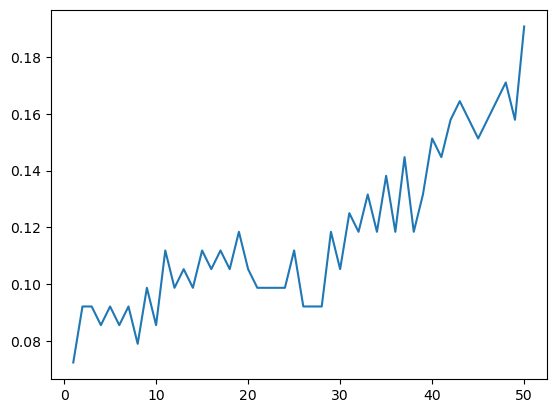

In [233]:
plt.plot(results["k"], results["error_rate"])

In [236]:
results.min()

k             1.000000
error_rate    0.072368
dtype: float64